In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ingredients.csv')
df

,sweetness,crunchiness,ingredients,class
0,1,1,cheese,protein
1,3,1,fish,protein
2,2,2,shrimp,protein
3,1,4,bacon,protein
4,3,5,nuts,protein
5,1,9,lettuce,vegetable
6,2,8,cucumber,vegetable
7,3,7,green bean,vegetable
8,5,10,carrot,vegetable
9,3,10,celery,vegetable


In [3]:
df.shape

(15, 4)

In [7]:
df.isnull().sum()

sweetness      0
crunchiness    0
ingredients    0
class          0
dtype: int64

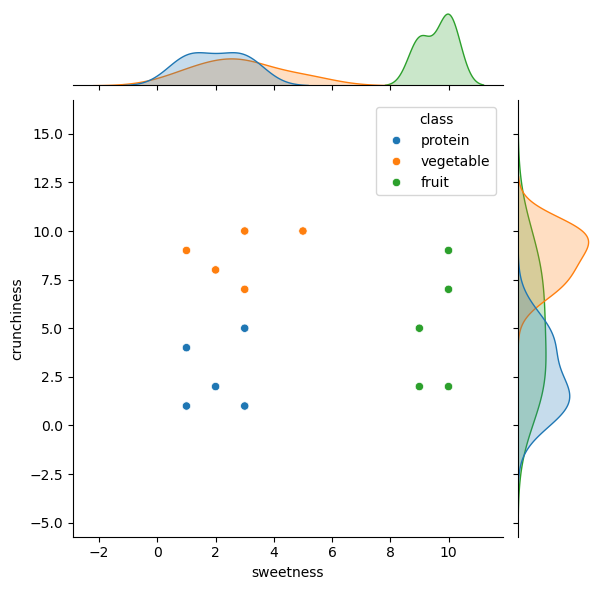

In [8]:
sns.jointplot(x = 'sweetness', y = 'crunchiness', data = df, hue = 'class');

In [9]:
x = df[['sweetness', 'crunchiness']]
y = df['class']

In [10]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 4)
knn.fit(x, y)

,n_neighbors,4
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
tomato = pd.DataFrame({
    'sweetness' : [6],
    'crunchiness' : [4]
})

In [12]:
knn.predict(tomato)

array(['fruit'], dtype=object)

In [2]:
df = sns.load_dataset('iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
df.shape

(150, 5)

In [4]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

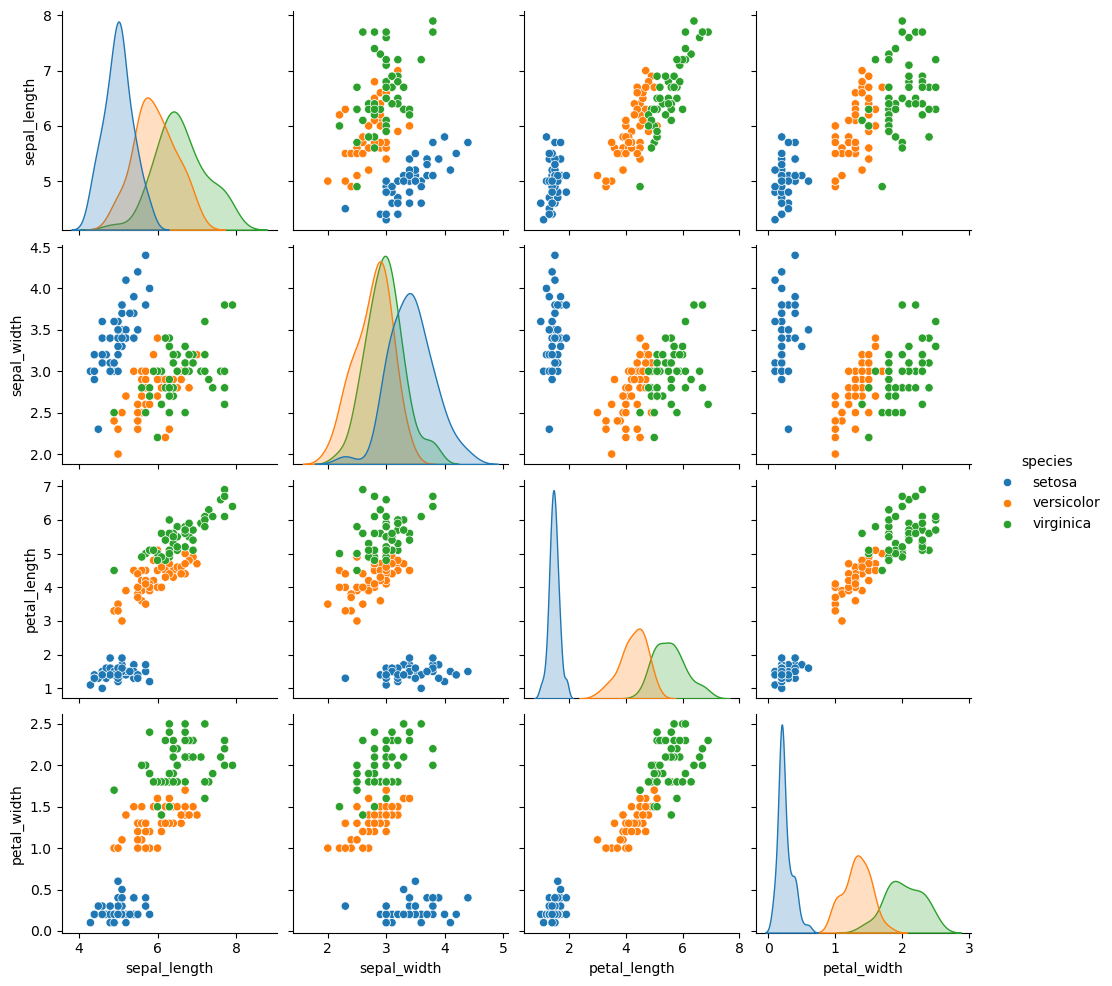

In [5]:
sns.pairplot(df, hue = 'species');

<Axes: xlabel='species', ylabel='count'>

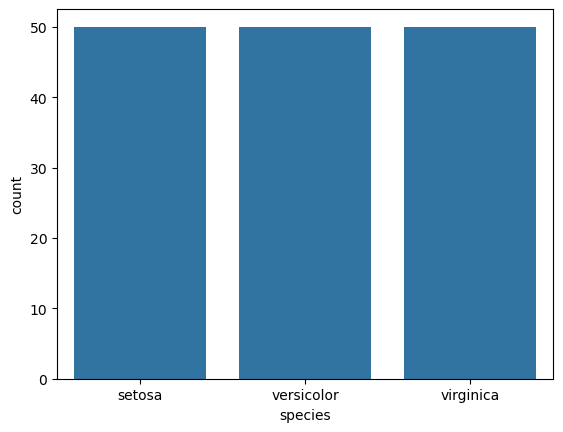

In [6]:
sns.countplot(x = df['species'])

In [7]:
x = df.drop('species', axis = 1)
y = df['species']

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 0, test_size = 0.25)

In [9]:
x_train.shape, y_train.shape

((112, 4), (112,))

In [10]:
x.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [11]:
from sklearn.preprocessing import MinMaxScaler
sca = MinMaxScaler()

In [12]:
x_train_scaled = sca.fit_transform(x_train)
x_test_scaled = sca.transform(x_test)

In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(x_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [14]:
y_pred = knn.predict(x_test_scaled)

In [15]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9736842105263158

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

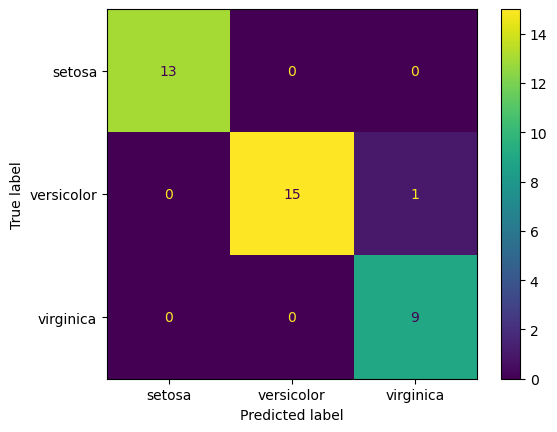

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

In [19]:
print(classification_report(y_test, y_pred));

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.94      0.97        16
   virginica       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



In [20]:
np.mean(y_test != y_pred)

np.float64(0.02631578947368421)

In [21]:
error = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors= k)
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)
    error_rate = np.mean(y_test!= y_pred)
    error.append(error_rate)

In [22]:
error;

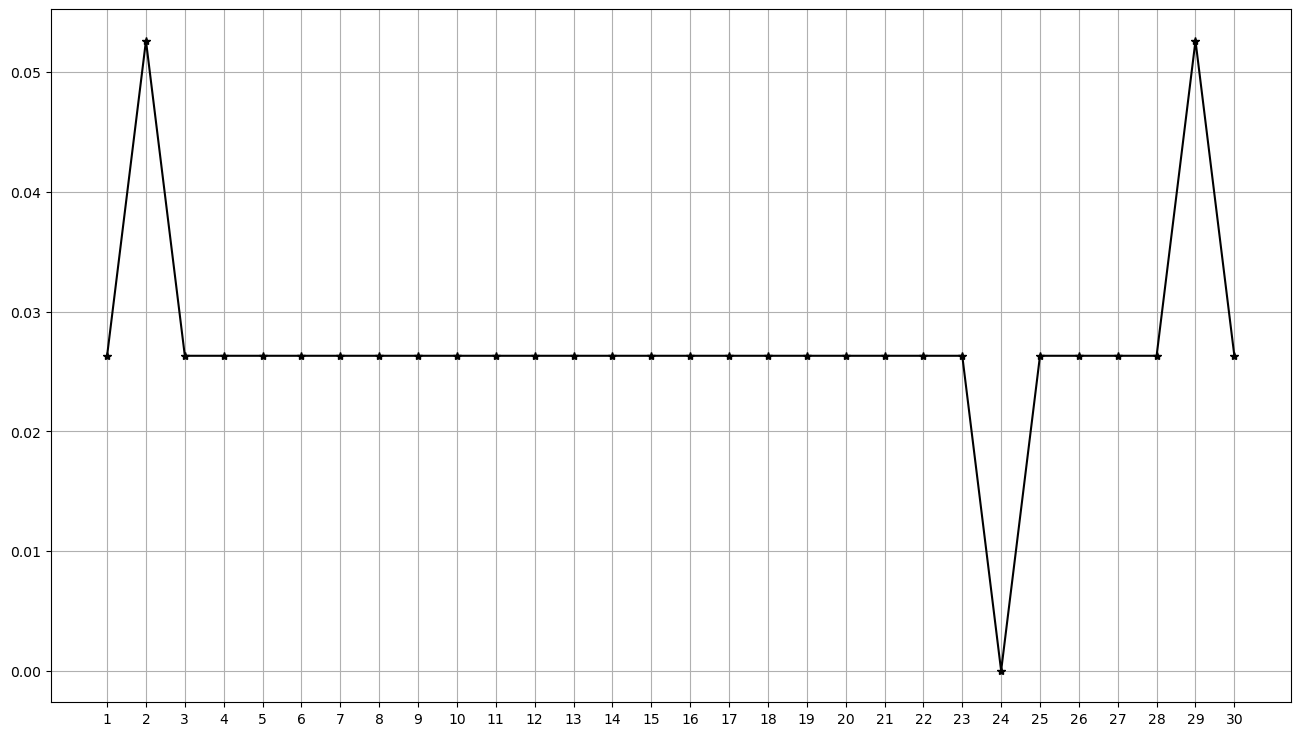

In [23]:
plt.figure(figsize=(16, 9))
plt.xticks(range(1,31,1))
plt.plot(range(1,31), error, marker = '*', color = 'black');
plt.grid()